In [19]:
from imagegrains import segmentation_helper, data_loader, plotting
from pathlib import Path
import torch
import matplotlib.pyplot as plt

## Download pre-trained models and demo data  
This notebook will try to use segementation results from the previous notebook **1_image_segmentation**.

In [20]:
download_path = Path.home().joinpath('imagegrains')
data_path = download_path.joinpath('demo_data','FH').as_posix()

## Check local GPU setup  
If you have a GPU, you can run the following cell to check if it is properly set up. Pleasse make sure to follow the instructions for correct installation in the [README](https://github.com/dmair1989/imagegrains#local-installation) to enable GPU support. If you work on a Mac you can try to install the Cellpose package with experimental M1 support (see [here](https://cellpose.readthedocs.io/en/latest/installation.html#m1-mac-installation)).

In [21]:
# List GPU devices and CUDA version
!nvidia-smi -L 
!nvcc --version
# Check GPU memory
!nvidia-smi -q -d Memory 

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available for pytorch: {torch.cuda.is_available()}")

zsh:1: command not found: nvidia-smi
zsh:1: command not found: nvcc
zsh:1: command not found: nvidia-smi
PyTorch version: 2.12.1
GPU available for pytorch: False


## Train models based on Cellpose-SAM  via default Cellpose training
Here we train a model for a set of images (usually own data combined with the data from https://zenodo.org/records/8005771). Requirements for the data are:
1) Each image file (ideally in `.jpg` format) needs a label file (with teh same name as the image and `_mask` at the end of the filename; as `.tif` with the exact same extend and resolution as the image file) that holds the ground truth masks (each grain has to have an individual label).
2) The images and masks should be split into a `test` and `train` subfolder. The `data_path` should refer to the parent folder (please use a full path).

In [22]:
# using the demo files
data_path = f'{download_path}/demo_data/FH/' 

# OR path to custom dataset (uncomment next line to use)
#data_path = "E:/David/cellpose/fh/" 

### Find files

In [23]:
train_images,train_masks,test_images,test_masks = data_loader.find_data(data_path)
print('Number of images:',len(train_images),'/',len(test_images))

Number of images: 6 / 1


### (Optional) Ensure correct names

In [24]:
segmentation_helper.check_labels(train_masks);
segmentation_helper.check_labels(test_masks);
segmentation_helper.check_im_label_pairs(train_images,train_masks);
segmentation_helper.check_im_label_pairs(test_images,test_masks);

No files renamed.
No files renamed.
All images have labels.
All images have labels.


### (Optional) Visual data check

Training images/labels


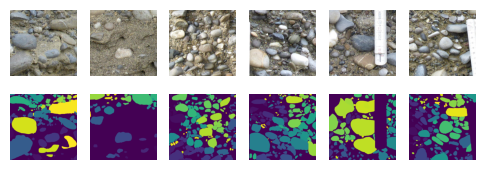

In [25]:
plt.figure(figsize=(len(train_images),2))
plotting.show_training_set(train_images)
print('Training images/labels')

Test images/labels


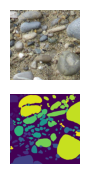

In [26]:
print('Test images/labels')
plt.figure(figsize=(len(test_images),2))
plotting.show_training_set(test_images)

For more options you can use the default training for cellpose (not recommended). Here you can use all of the `CellposeModel.train()` parameters:   
https://cellpose.readthedocs.io/en/latest/api.html#module-cellpose.train

In [27]:
from cellpose import models, io, train

io.logger_setup()

#The Cellpose model needs the images pre-loaded. 
train_data,train_labels,test_data,test_labels = [],[],[],[]
for x1,y1 in zip(train_images,train_masks):
    train_data.append(io.imread(str(x1)))
    train_labels.append(io.imread(str(y1)))

for x2,y2 in zip(test_images,test_masks):
    test_data.append(io.imread(str(x2)))
    test_labels.append(io.imread(str(y2)))

#create model object
model = models.CellposeModel(gpu=True,use_bfloat16=True)
masks_ext = "_mask"
model_name = "IG2_cpSAM_new_model"
#train (uncomment next lines to use)
new_model_path, train_losses, test_losses = train.train_seg(model.net,
                                                            n_epochs = 5,
                                                            train_data=train_data,
                                                            train_labels=train_labels,
                                                            test_data=test_data,
                                                            test_labels=test_labels,
                                                            model_name=model_name,
                                                            )

[GUI INFO] : WRITING LOG OUTPUT TO /Users/david/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	darwin 
python version: 	3.10.20 
torch version:  	2.12.1
2026-09-04 14:52:50,277 [io INFO] WRITING LOG OUTPUT TO /Users/david/.cellpose/run.log
2026-09-04 14:52:50,277 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	darwin 
python version: 	3.10.20 
torch version:  	2.12.1
2026-09-04 14:52:50,288 [core INFO] ** TORCH MPS version installed and working. **
2026-09-04 14:52:50,288 [core INFO] >>>> using GPU (MPS)
2026-09-04 14:52:50,831 [models INFO] >>>> loading model /Users/david/.cellpose/models/cpsam_v2
2026-09-04 14:52:51,108 [train INFO] >>> converting bfloat16 network to float32 for training
2026-09-04 14:52:51,135 [dynamics INFO] computing flows for labels


100%|██████████| 6/6 [00:00<00:00,  8.82it/s]

2026-09-04 14:52:51,818 [dynamics INFO] computing flows for labels


2026-09-04 14:52:51,931 [train INFO] >>> computing diameters


100%|██████████| 1/1 [00:00<00:00, 1236.16it/s]

2026-09-04 14:52:51,939 [train INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}
2026-09-04 14:52:51,977 [train INFO] >>> n_epochs=5, n_train=6, n_test=1, bsize=256, batch_size=1, nimg_per_epoch=6
2026-09-04 14:52:51,978 [train INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.10000
2026-09-04 14:52:51,979 [train INFO] >>> saving model to /Users/david/ig_dev/imagegrains/notebooks/models/IG2_cpSAM_new_model


2026-09-04 14:52:55,938 [train INFO] 0, train_loss=1.9064, test_loss=1.9203, LR=0.000000, time 3.96s
2026-09-04 14:53:11,006 [train INFO] saving network parameters to /Users/david/ig_dev/imagegrains/notebooks/models/IG2_cpSAM_new_model
2026-09-04 14:53:12,708 [train INFO] >>> converting network back to torch.bfloat16 after training
